# 01 - HPC Job Energy and Emissions Prediction

Goal: estimate job energy consumption from features available in the HPC trace, compare multiple candidate models, select the best one on a chronological validation split, and convert predictions into emissions using a synthetic carbon-intensity signal in gCO2/kWh.

This notebook is a presentation-oriented view of the results. The reproducible computation lives in `scripts/01_run_carbon_prediction.py` and `src/hpc_carbon_scheduler/carbon_model.py`.


In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

PROJECT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = PROJECT / 'results' / 'carbon_prediction'
sys.path.insert(0, str(PROJECT / 'src'))

print('Project root detected')
print('Results directory:', RESULTS.relative_to(PROJECT))


Project root detected
Results directory: results\carbon_prediction


## Result Generation

If the files in `results/carbon_prediction` do not exist yet, run this from the terminal:

```bash
python scripts/01_run_carbon_prediction.py --max-rows 60000
```

In [2]:
metrics = pd.read_csv(RESULTS / 'metrics.csv')
metrics.T.rename(columns={0: 'value'})

,value
selected_model,hist_gradient_boosting
selection_metric,validation_energy_r2
selected_validation_energy_r2,0.55586
selected_validation_energy_mae_kwh,6.407521
rows_total,58846.0
rows_train,35307.0
rows_validation,11769.0
rows_test,11770.0
test_energy_mae_kwh,5.807825
test_energy_rmse_kwh,33.131747


## Model Selection

The project keeps the research step visible: several regressors are compared on validation data before choosing the model used by the scheduler.


In [3]:
comparison = pd.read_csv(RESULTS / 'model_comparison.csv')
comparison


,model,validation_energy_mae_kwh,validation_energy_rmse_kwh,validation_energy_r2,validation_emissions_mae_kg,validation_emissions_rmse_kg,validation_emissions_r2
0,hist_gradient_boosting,6.407521,29.815607,0.555860,2.302725,10.579623,0.532104
1,random_forest,6.653561,30.910670,0.522636,2.395515,11.015828,0.492725
2,extra_trees,7.177292,35.474610,0.371264,2.569164,12.416256,0.355548
3,ridge_regression,9.283853,46.854056,-0.096800,3.294858,16.282323,-0.108260


## Interpretation

- `model_comparison.csv` reports the models tested during the research phase.
- The selected model is the one with the highest `validation_energy_r2`.
- Final metrics in `metrics.csv` are computed on the chronological test split after retraining the selected model on train + validation.
- The model uses only features available, or reasonably known, at job submission time: requested resources, time limit, and temporal features.
- `job_predictions.csv` stores predictions for all valid jobs and includes the `split` and `selected_model` columns.


In [4]:
feature_importance = pd.read_csv(RESULTS / 'feature_importance.csv')
feature_importance

,feature,importance
0,time_limit,0.913267
1,mem_req,0.547531
2,num_gpus_req,0.375292
3,num_nodes_req,0.259372
4,num_tasks,0.205396
5,hour,0.144746
6,weekday,0.088704
7,num_cores_req,0.063693
8,cores_per_task,0.047901
9,month,0.012524


## Main Plots

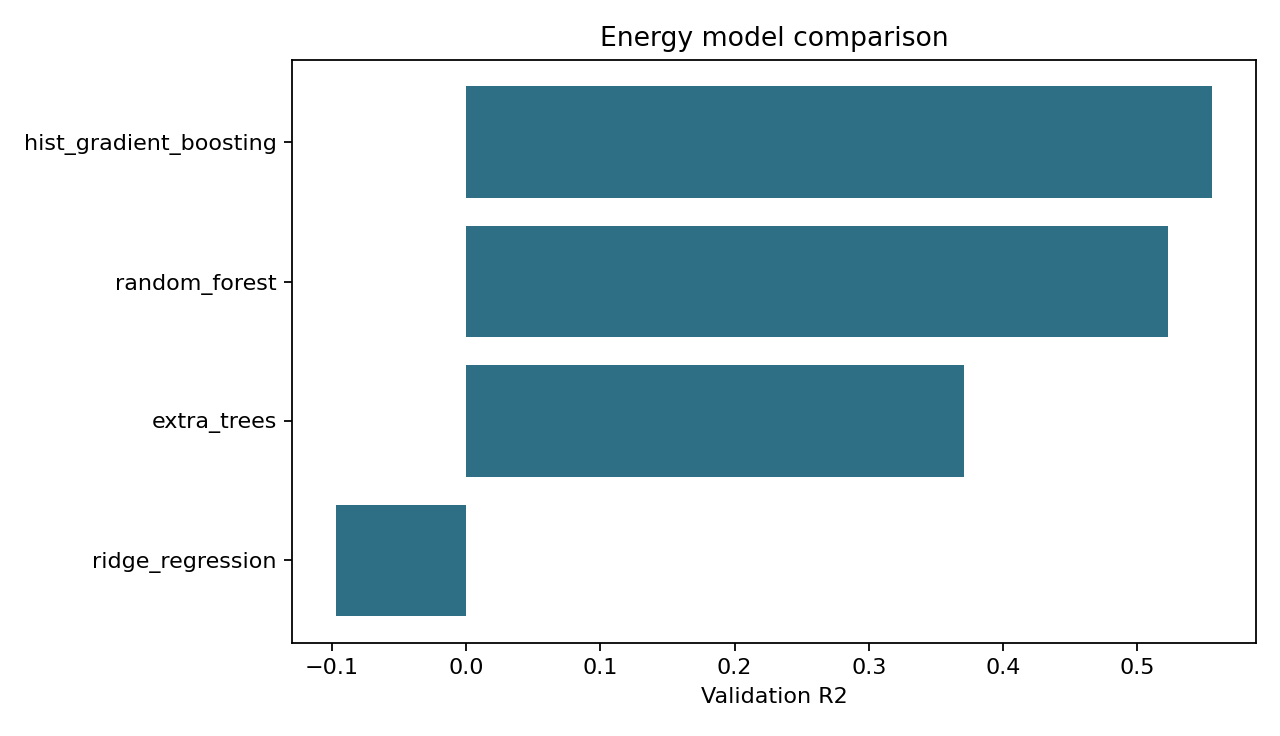

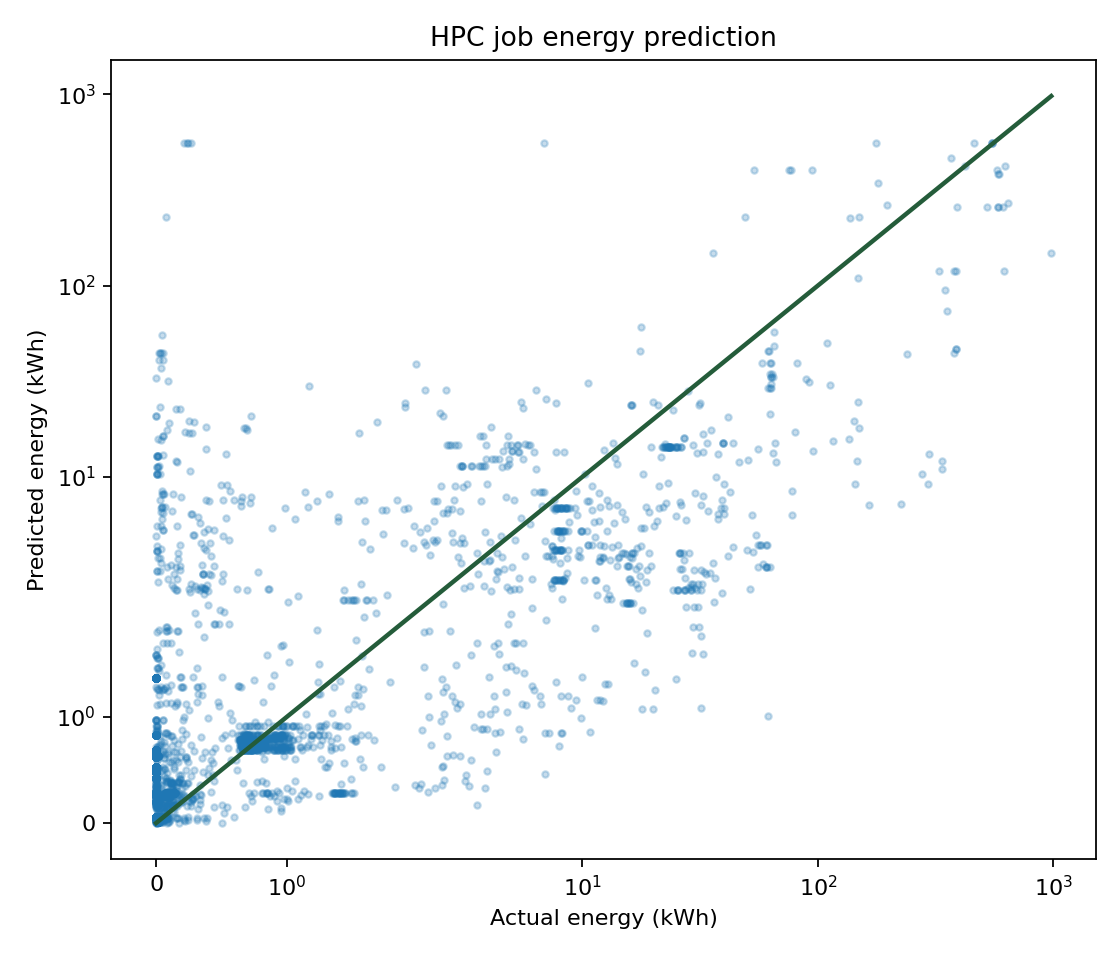

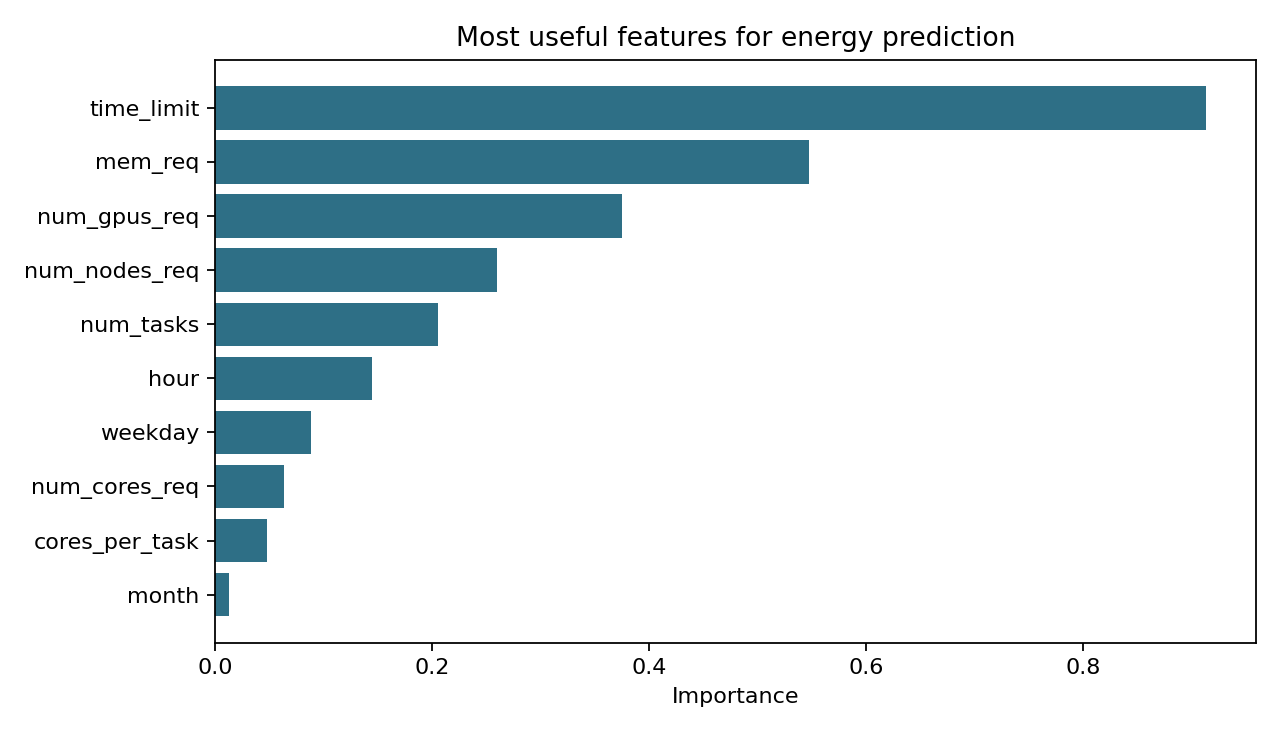

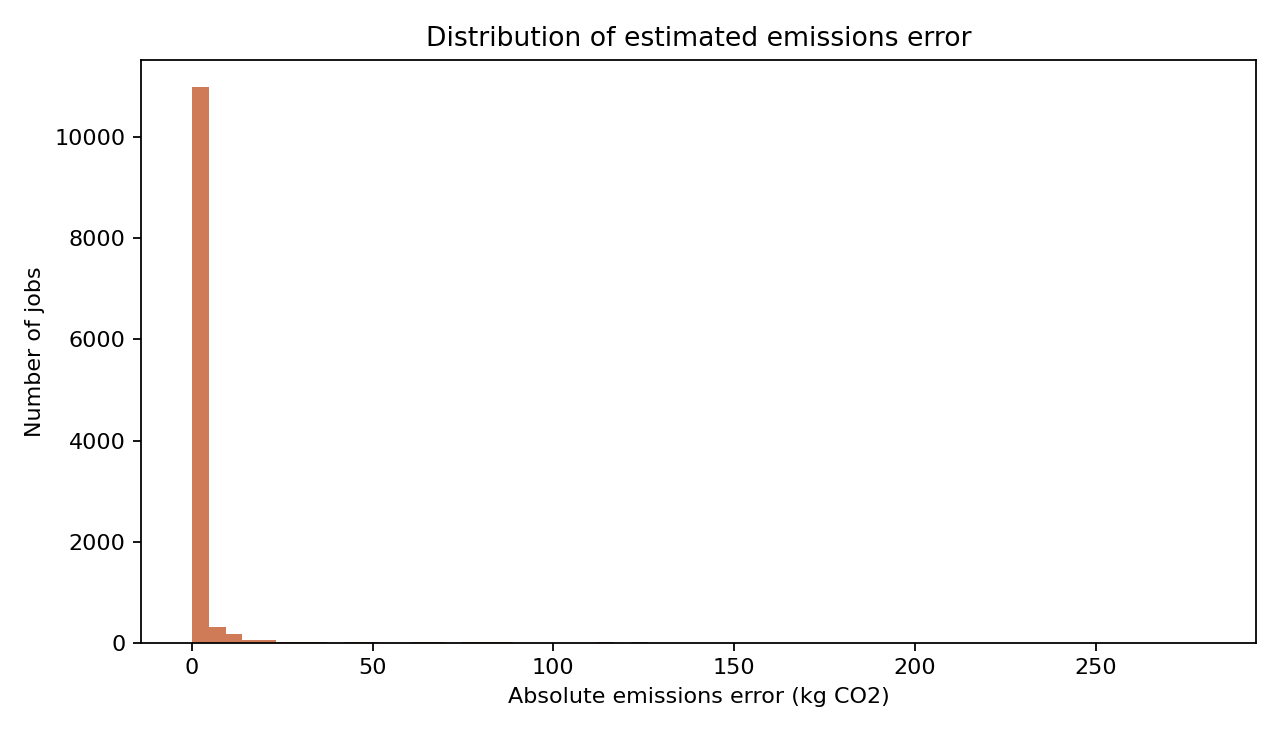

In [5]:
for name in ['model_comparison_validation_r2.png', 'energy_actual_vs_predicted.png', 'feature_importance.png', 'emissions_error_histogram.png']:
    display(Image(filename=str(RESULTS / name)))


## Prediction Examples

In [6]:
pred = pd.read_csv(RESULTS / 'job_predictions.csv')
print(pred['split'].value_counts().to_string())
cols = ['job_id', 'split', 'run_time', 'num_nodes_req', 'energy_kwh', 'pred_energy_kwh', 'emissions_kg', 'pred_emissions_kg']
pred[cols].head(15)

split
train         35307
test          11770
validation    11769


,job_id,split,run_time,num_nodes_req,energy_kwh,pred_energy_kwh,emissions_kg,pred_emissions_kg
0,5370710,train,13243,1,3.629351,9.100996,0.655082,1.642689
1,175694,train,19576,8,44.837986,5.306639,7.550412,0.893602
2,2214444,train,17052,13,40.172673,37.696065,7.703273,7.228374
3,2687047,train,19869,16,87.687426,8.803419,16.964455,1.703154
4,4281751,train,7342,9,15.271026,3.363775,2.667659,0.587610
5,584948,train,6749,4,5.185669,1.236651,0.936155,0.223249
6,3192383,train,12996,1,3.654979,0.461551,0.706864,0.089263
7,3783714,train,36027,13,81.527539,34.953789,15.441377,6.620274
8,3096661,train,8499,6,9.942273,1.588081,1.909868,0.305064
9,4678367,train,10703,1,2.251097,0.382639,0.415484,0.070623


## Key Message

The first phase is not a single fixed model. It compares Ridge Regression, Random Forest, Extra Trees, and HistGradientBoosting on a chronological validation split. The best validation model is then used to generate `pred_energy_kwh`, which is the scheduler input in the second phase.
